In [4]:
print("Hello World")

Hello World


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from sklearn.metrics import mean_absolute_error, r2_score


In [4]:
df_daily=pd.read_csv("Final_data.csv")
df_daily.head()

,Datetime,Global_active_power
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


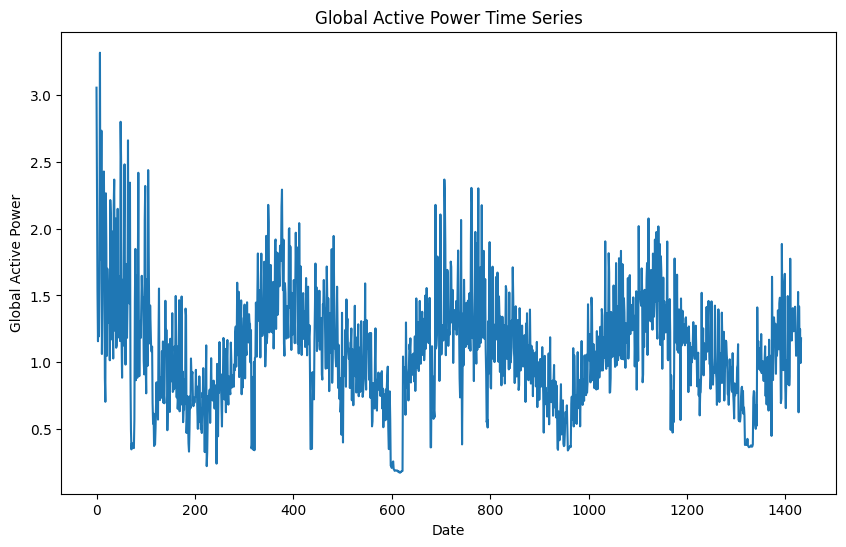

In [5]:
# Plot the time series to visualize
df_daily['Global_active_power'].plot(figsize=(10, 6))
plt.title('Global Active Power Time Series')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.show()


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import aic

# Define the parameter grid
p_values = range(1, 6)    # AR terms (p)
q_values = range(1, 6)    # MA terms (q)
P_values = range(1, 3)    # Seasonal AR terms (P)
Q_values = range(1, 3)    # Seasonal MA terms (Q)
s = 15                   # Seasonal period (15 days for your case)

# Initialize a variable to store the best parameters and AIC
best_aic = float("inf")
best_order = None
best_seasonal_order = None

# Iterate over all combinations of the parameter grid
for p in p_values:
    for q in q_values:
        for P in P_values:
            for Q in Q_values:
                try:
                    # Fit the SARIMA model
                    model = SARIMAX(df_daily['Global_active_power'],
                                    order=(p, 0, q),
                                    seasonal_order=(P, 1, Q, s),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)
                    results = model.fit(disp=False)
                    
                    # Get the AIC value for the current model
                    aic_value = results.aic
                    
                    # If AIC is better, update the best parameters
                    if aic_value < best_aic:
                        best_aic = aic_value
                        best_order = (p, 0, q)
                        best_seasonal_order = (P, 1, Q, s)
                        
                except Exception as e:
                    continue  # Skip if the model fails to fit

# Display the best parameters and the corresponding AIC value
print(f"Best AIC: {best_aic}")
print(f"Best order: {best_order}")
print(f"Best seasonal order: {best_seasonal_order}")


C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Roaming\Python\P

KeyboardInterrupt: 

In [20]:
# Define the SARIMA model (adjusting the seasonal period to 15)
sarima_model = SARIMAX(df_daily['Global_active_power'],
                       order=(5, 0, 1),   # p, d, q (Non-seasonal)
                       seasonal_order=(1, 0, 1, 7),  # P, D, Q, S (Seasonal) with S = 15 (period)
                       enforce_stationarity=False,   # Don't enforce stationarity on residuals
                       enforce_invertibility=False)  # Don't enforce invertibility of ARMA terms

# Fit the model
sarima_result = sarima_model.fit(disp=False)

# Print the model summary
print(sarima_result.summary())


                                     SARIMAX Results                                     
Dep. Variable:               Global_active_power   No. Observations:                 1433
Model:             SARIMAX(5, 0, 1)x(1, 0, 1, 7)   Log Likelihood                -240.292
Date:                           Tue, 22 Apr 2025   AIC                            498.584
Time:                                   14:09:34   BIC                            545.916
Sample:                                        0   HQIC                           516.265
                                          - 1433                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.2854      0.023     56.888      0.000       1.241       1.330
ar.L2         -0.2700      0.032     -8.396

C:\Users\HP\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


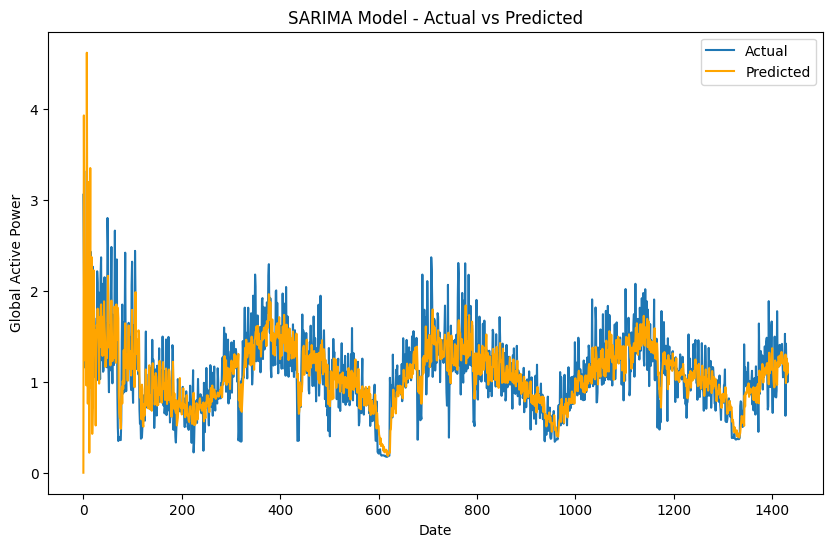

In [21]:
# In-sample predictions
df_daily['SARIMA_pred'] = sarima_result.fittedvalues

# Plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_daily['Global_active_power'], label='Actual')
plt.plot(df_daily['SARIMA_pred'], label='Predicted', color='orange')
plt.title('SARIMA Model - Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Global Active Power')
plt.legend()
plt.show()


In [22]:
# Calculate the evaluation metrics
mae = mean_absolute_error(df_daily['Global_active_power'], df_daily['SARIMA_pred'])
rmse_value = rmse(df_daily['Global_active_power'], df_daily['SARIMA_pred'])
r2 = r2_score(df_daily['Global_active_power'], df_daily['SARIMA_pred'])

# Print the evaluation results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Squared Error (RMSE): {rmse_value}')
print(f'R² Score: {r2}')


Mean Absolute Error (MAE): 0.21995782030682917
Root Mean Squared Error (RMSE): 0.3180382216302954
R² Score: 0.4273299767103653
